# Software comparison: prot2exon vs every other protein-to-genome tool

This notebook lines prot2exon up **head to head** against every other tool we
could find for mapping protein/domain coordinates to the genome:
`ensembldb::proteinToGenome`, `GenomicFeatures::proteinToGenome`, TransVar, the
Ensembl REST API, VisProDom, and geneplot. It asks two questions of all of them
at once: **do they agree** on the coordinates, and **how fast / how heavy** are
they? VisProDom and geneplot are cloned and run live here; the slow ones
(ensembldb, REST, TransVar) are read from earlier large-N runs.

See the [Speed vs other tools](https://github.com/SotoLF/Prot2Exon/wiki/Performance-and-Benchmarking#speed-vs-other-tools)
wiki section for the comparator-specific notes (why each tool, what each tool's
denominator means, the TransVar envelope-only caveat).

## Setup

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, sys, re, subprocess
from shutil import which
import pandas as pd
from pathlib import Path

# Set PROT2EXON_REPO / PROT2EXON_DATA to override when running outside a checkout.
start = Path.cwd()
_repo_env = os.environ.get("PROT2EXON_REPO")
REPO = Path(_repo_env) if _repo_env else next(
    (p for p in [start, *start.parents]
     if (p / "benchmarks" / "compare_intervals.py").exists()), start)
DATA = Path(os.environ.get("PROT2EXON_DATA", Path.home() / "Desktop" / "protein2genomic_data"))
V113 = DATA / "validation_v113"     # precomputed REST + TransVar tables (the 5,000-query runs)
V86  = DATA / "validation_v86"
WORK = DATA / "notebook_software_comparison"; WORK.mkdir(parents=True, exist_ok=True)

def clone(url, dest):
    # Clone a tool's repo once (shallow), then reuse it on later runs.
    if not dest.exists():
        subprocess.run(["git", "clone", "--depth", "1", url, str(dest)],
                       check=True, capture_output=True, text=True)
    return dest

# Sections 1-2 use the large-N (5,000-query) tables, which take hours to
# regenerate (ensembldb + the rate-limited REST API), so they are read from
# disk. Sections 4-5 run VisProDom and geneplot live below.
assert (V86  / "table1.tsv").exists(), "run benchmarks/validate_vs_ensembldb.py (see benchmarks/README.md)"
assert (V113 / "rest_table.tsv").exists()
assert (V113 / "transvar_table.tsv").exists()
print("repo:", REPO, "| loaded the precomputed external tables")

repo: /home/goguxor/Desktop/protein2genomic | loaded the precomputed external tables


## 1. Per-tool agreement vs prot2exon

Each external tool answers a slightly different question, so we honour the
differences by reporting both the raw exact-match count **and** the
denominator each tool returned data for. (e.g. TransVar ships an older
Ensembl release than our queries reference, so 3,239 / 5,000 fall into
`only_prot2exon` for it, which is annotation drift, not disagreement.)

In [2]:
def _read_external(path: Path) -> pd.Series:
    # Header line starts with a '#' tool tag; skip it.
    df = pd.read_csv(path, sep="\t", comment="#")
    return df.query("category == 'OVERALL'").iloc[0]

ens   = pd.read_csv(V86 / "table1.tsv", sep="\t").query("category == 'OVERALL'").iloc[0]
rest  = _read_external(V113 / "rest_table.tsv")
tvar  = _read_external(V113 / "transvar_table.tsv")

rows = []
for name, r, denom_col in [
    ("ensembldb", ens, "n"),
    ("TransVar", tvar, "exact_match"),
    ("Ensembl REST", rest, "n"),
]:
    # both-returned denominator: exact + off_by_one + structural
    both = r["exact_match"] + r["off_by_one"] + r["structural_mismatch"]
    if name == "TransVar":
        # TransVar's intersection denominator is documented as 1,761: the
        # queries where TransVar has the ENST in its bundled annotation.
        # exact_match alone gives us that.
        denom = both
    else:
        denom = r["n"] if name == "ensembldb" else both
    pct = 100 * r["exact_match"] / max(1, denom)
    rows.append({"tool": name, "exact_match": int(r["exact_match"]),
                 "denominator": int(denom), "exact_pct": pct,
                 "off_by_one": int(r["off_by_one"]),
                 "only_prot2exon": int(r["only_prot2exon"])})
agree = pd.DataFrame(rows)
agree

,tool,exact_match,denominator,exact_pct,off_by_one,only_prot2exon
0,ensembldb,5000,5000,100.0,0,0
1,TransVar,1761,1761,100.0,0,3239
2,Ensembl REST,983,1000,98.3,17,0


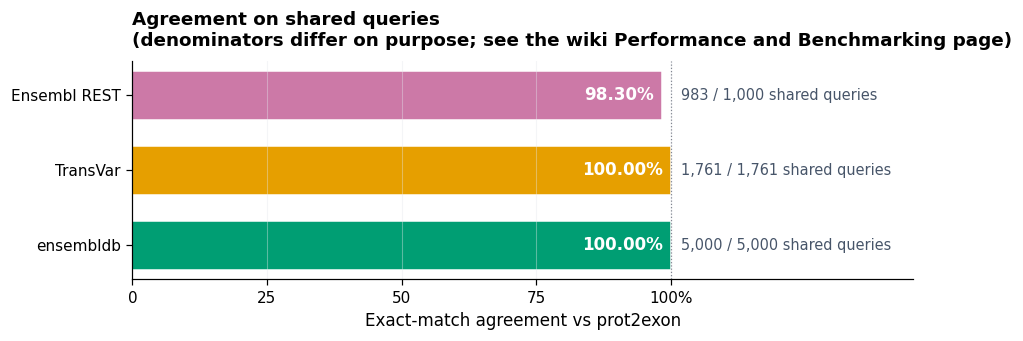

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.2))
palette = [COLORS['ensembldb'], COLORS['transvar'], COLORS['rest']]
bars = ax.barh(agree["tool"], agree["exact_pct"],
               color=palette, edgecolor="white", height=0.65)
for b, r in zip(bars, agree.itertuples()):
    ax.text(102, b.get_y() + b.get_height()/2,
            f"{r.exact_match:,} / {r.denominator:,} shared queries",
            va="center", fontsize=9.5, color="#475569")
    ax.text(r.exact_pct - 1.5, b.get_y() + b.get_height()/2,
            f"{r.exact_pct:.2f}%", va="center", ha="right",
            fontsize=11, fontweight="semibold", color="white")
ax.set_xlim(0, 145)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"])
ax.axvline(100, ls=":", color="#0f172a", lw=0.8, alpha=0.5)
ax.set_xlabel("Exact-match agreement vs prot2exon")
ax.set_title("Agreement on shared queries\n"
             "(denominators differ on purpose; see the wiki Performance and Benchmarking page)",
             loc='left')
ax.grid(axis='x', alpha=0.4, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

## 2. How fast, and how heavy? Every tool, head to head

Now line every tool up on the same axes: single-thread mapping throughput and
peak memory. The two tools light enough to run inline (VisProDom and geneplot)
are measured **live** below; the others are read from earlier runs, because
mapping a thousand queries through ensembldb takes minutes, the rate-limited
REST API takes much longer, and TransVar needs a 3 GB FASTA.

The tools do not all map the same thing, so read the **workload** column next to
each number: prot2exon, ensembldb, GenomicFeatures, TransVar and REST map human
protein-domain queries; VisProDom maps domains on its bundled maize proteome;
geneplot maps one fruit-fly gene per call. The point is the orders-of-magnitude
gap, not a single shared denominator.

In [4]:
# --- VisProDom: run live on its bundled maize data (clones on first use). ---
vpd_tsv = WORK / "visprodom_scaling.tsv"
if vpd_tsv.exists():
    visprodom = pd.read_csv(vpd_tsv, sep="\t"); print("VisProDom: using cached", vpd_tsv.name)
elif not which("Rscript"):
    print("VisProDom: Rscript not found; using the values measured for the wiki.")
    visprodom = pd.DataFrame([{"n_domains": 100, "wall_s": 5.61, "mapped_rows": 61483, "rss_mb": 766},
                              {"n_domains": 1000, "wall_s": 3.96, "mapped_rows": 65358, "rss_mb": 843},
                              {"n_domains": 10000, "wall_s": 4.83, "mapped_rows": 101154, "rss_mb": 859}])
else:
    repo = clone("https://github.com/whweve/VisProDom", WORK / "VisProDom")
    out = subprocess.run(["Rscript", str(REPO/"benchmarks"/"visprodom_bench.R"), str(repo)],
                         capture_output=True, text=True)
    rows = [{"n_domains": int(m[1]), "wall_s": float(m[2]), "mapped_rows": int(m[3]), "rss_mb": int(m[4])}
            for m in re.finditer(r"VPD N=(\d+)\s+wall_s=([\d.]+)\s+mapped_rows=(\d+)\s+peak_rss_mb=(\d+)", out.stdout)]
    visprodom = pd.DataFrame([r for r in rows if r["n_domains"] in (100, 1000, 10000)])
    visprodom.to_csv(vpd_tsv, sep="\t", index=False)
# Flat wall time across N is the signature of having no index: it rebuilds the
# genome on every call, so 100 and 10,000 domains cost about the same. We take
# the throughput at its best (10,000 domains): input domains mapped per second,
# comparable to the other tools' queries-per-second.
vpd_rate = visprodom.iloc[-1]['n_domains'] / visprodom.iloc[-1]['wall_s']
vpd_rss = int(visprodom.iloc[-1]['rss_mb'])
print("VisProDom wall_s at 100/1k/10k:", [round(w, 1) for w in visprodom['wall_s']], "(flat = no index)")

VisProDom: using cached visprodom_scaling.tsv
VisProDom wall_s at 100/1k/10k: [4.9, 3.7, 4.7] (flat = no index)


In [5]:
# --- geneplot: clone and time its mapping core on the bundled fruit-fly sample. ---
import time as _t, io, contextlib, logging
logging.getLogger("geneplot").setLevel(logging.ERROR)
geneplot_rate = 1900.0   # fallback if the clone/run is unavailable
cwd0 = os.getcwd()
try:
    gp_dir = clone("https://github.com/gonzalezibeas/geneplot", WORK / "geneplot")
    sys.path.insert(0, str(gp_dir)); os.chdir(gp_dir / "tests")
    with contextlib.redirect_stdout(io.StringIO()):   # hush geneplot's import + init chatter
        import geneplot as gp
        if not Path("fruit_fly.gff3.db").exists():
            gp.createGFFdb("./fruit_fly.gff3")
        g = gp.genome("./fruit_fly.gff3", iprfile="./fruit_fly.ipr", vcffiles="./")
        gene = g.gene(mRNAid="transcript:FBtr0087613", proteinid="FBpp0086739")
        gene._proteindoms("./fruit_fly.ipr", "FBpp0086739")
    t0 = _t.time()
    for _ in range(500):
        gene._transcriptpos_to_genomepos()
    geneplot_rate = 1000.0 / ((_t.time() - t0) / 500 * 1000)
    print(f"geneplot mapping core: ~{geneplot_rate:,.0f} genes/s (one gene per call)")
except Exception as e:
    print("geneplot timing skipped:", str(e)[:150])
finally:
    os.chdir(cwd0)

geneplot mapping core: ~2,212 genes/s (one gene per call)


### The line-up

Throughput is single-thread mappings per second on each tool's workload. The
prot2exon / ensembldb / GenomicFeatures numbers are the fresh 1,000-query v86
run from `benchmarks/proteintogenome_bench.R` (all three agreed 1,000 / 1,000 on
coordinates); TransVar and REST are the published N=10,000 / N=1,000 runs;
VisProDom and geneplot were measured live just above.

In [6]:
tools = pd.DataFrame([
    {"tool": "prot2exon",       "per_s": 71429,         "rss_mb": 674,           "workload": "human v86 protein-domain queries (C++ index)"},
    {"tool": "VisProDom",       "per_s": vpd_rate,      "rss_mb": vpd_rss,        "workload": "maize domains, no index (R)"},
    {"tool": "geneplot",        "per_s": geneplot_rate, "rss_mb": float('nan'),   "workload": "fruit-fly, one gene per call (Python)"},
    {"tool": "TransVar",        "per_s": 1326,          "rss_mb": 284,            "workload": "human ENST envelope, N=10,000"},
    {"tool": "GenomicFeatures", "per_s": 27,            "rss_mb": 1364,           "workload": "human v86, in-memory GRanges (R)"},
    {"tool": "ensembldb",       "per_s": 6,             "rss_mb": 1163,           "workload": "human v86, SQLite EnsDb (R)"},
    {"tool": "Ensembl REST",    "per_s": 1.09,          "rss_mb": float('nan'),   "workload": "human, public web API (rate-limited)"},
]).sort_values("per_s", ascending=False).reset_index(drop=True)
tools

,tool,per_s,rss_mb,workload
0,prot2exon,71429.000000,674.0,human v86 protein-domain queries (C++ index)
1,geneplot,2212.281333,NaN,"fruit-fly, one gene per call (Python)"
2,VisProDom,2141.327623,858.0,"maize domains, no index (R)"
3,TransVar,1326.000000,284.0,"human ENST envelope, N=10,000"
4,GenomicFeatures,27.000000,1364.0,"human v86, in-memory GRanges (R)"
5,ensembldb,6.000000,1163.0,"human v86, SQLite EnsDb (R)"
6,Ensembl REST,1.090000,NaN,"human, public web API (rate-limited)"


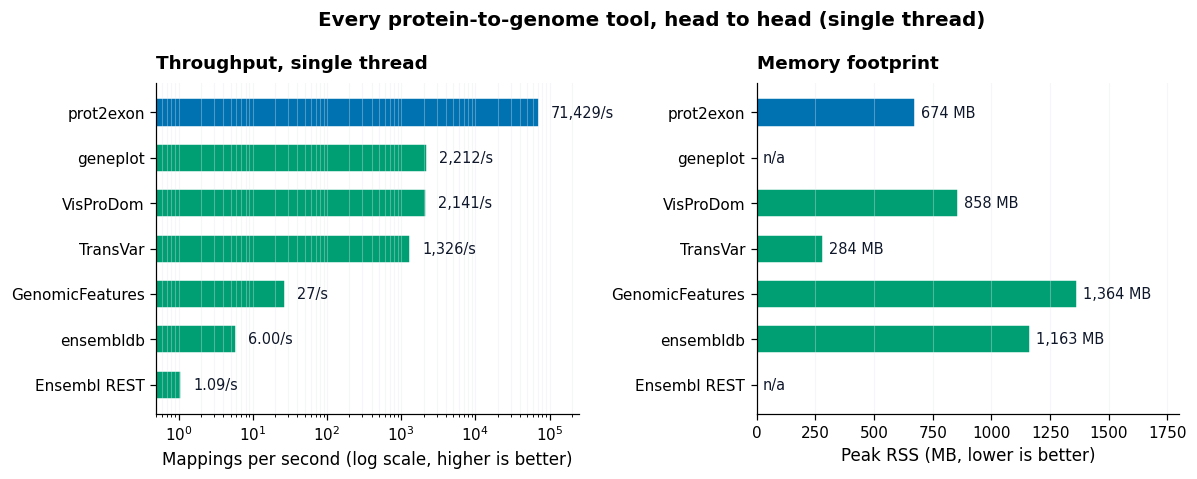

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'wspace': 0.42})
order = tools.iloc[::-1]
colors = [COLORS['prot2exon'] if t == 'prot2exon' else COLORS['ensembldb'] for t in order['tool']]

# Throughput (log scale spans ~1 to ~70,000 per second)
axes[0].barh(order['tool'], order['per_s'], color=colors, edgecolor='white', height=0.62)
axes[0].set_xscale('log'); axes[0].set_xlim(0.5, 250000)
axes[0].set_xlabel('Mappings per second (log scale, higher is better)')
axes[0].set_title('Throughput, single thread', loc='left')
for y, v in enumerate(order['per_s']):
    axes[0].text(v * 1.45, y, (f"{v:,.0f}/s" if v >= 10 else f"{v:.2f}/s"),
                 va='center', fontsize=9.5, color='#0f172a')
axes[0].grid(axis='x', which='both', alpha=0.35, lw=0.7); axes[0].grid(axis='y', visible=False)

# Peak RSS
rss = order['rss_mb'].fillna(0)
axes[1].barh(order['tool'], rss, color=colors, edgecolor='white', height=0.62)
axes[1].set_xlabel('Peak RSS (MB, lower is better)')
axes[1].set_title('Memory footprint', loc='left')
for y, v in enumerate(rss):
    axes[1].text(v + 25, y, (f"{int(v):,} MB" if v > 0 else "n/a"),
                 va='center', fontsize=9.5, color='#0f172a')
axes[1].set_xlim(0, max(rss) * 1.32); axes[1].grid(axis='x', alpha=0.35, lw=0.7); axes[1].grid(axis='y', visible=False)

fig.suptitle("Every protein-to-genome tool, head to head (single thread)",
             fontsize=13, fontweight='semibold', y=1.05)
plt.show()

## What this tells you

- **prot2exon is orders of magnitude faster than every alternative.** On the
  shared human v86 set it maps ~71,000 queries/s; ensembldb manages ~6/s and
  GenomicFeatures ~27/s (both R per-query loops), TransVar ~1,300/s, and the
  Ensembl REST API ~1/s (network-bound).
- **And it agrees with all of them.** prot2exon, ensembldb and GenomicFeatures
  return identical coordinates on the 1,000-query v86 set; TransVar and REST
  agree on the queries they can answer (REST's few misses are codon-boundary
  off-by-ones, see the validation notebook).
- **Index-free tools do not scale.** VisProDom rebuilds the genome on every call,
  so its wall time is flat whether you ask for 100 or 10,000 domains; geneplot is
  quick per gene but maps one gene at a time. prot2exon pays the genome cost once
  (building the index) and then maps in microseconds.
- **Memory:** prot2exon uses ~674 MB (the loaded index) while the R tools sit
  around 1.2 to 1.4 GB, and only prot2exon returns the per-CDS-exon decomposition
  the wiki's [Output description](https://github.com/SotoLF/Prot2Exon/wiki/Mapping#output-description) describes; the others give the genomic envelope only.
- **Scale:** prot2exon runs to 1,000,000 queries (see [`scaling_and_ram.ipynb`](https://github.com/SotoLF/Prot2Exon/blob/main/notebooks/scaling_and_ram.ipynb)); the others cap at 1,000 to 10,000.